# Stage 4: Analytical Fidelity of FHIR Data Representations

**Research objective.** Stages 1-3 measured, dimension by dimension, how much information
survives when canonical FHIR R4 data is transformed into two analytical representations. This
notebook asks a different question: **do the measured information-preservation differences
actually change the result of a downstream analytical query?**

Three representations are compared, all built from the same ~100-patient dataset:

- **R0** - the canonical FHIR R4 source representation. Used throughout as the *reference*
  representation against which R1 and R2 are scored.
- **R1** - a structure-preserving, normalized analytical representation.
- **R2** - an aggressively flattened, wide/tabular analytical representation.

For four analytical workloads (`W1`-`W4`), each representation is evaluated on two independent
axes:

- **Query feasibility** - can the representation express the analytical question at all?
- **Analytical-result fidelity** - when a query *is* expressible, does it return the same result
  as R0 (Precision / Recall / F1)?

These axes are kept strictly separate: a workload that cannot be expressed against a
representation is **not** scored as a fidelity failure (F1 = 0); it is recorded as
`query_feasible = False`, a capability limitation rather than an incorrect result.

**Scope constraints.** R0, R1 and R2 are frozen inputs (Stage 3 outputs) and are not redesigned,
patched, or backfilled here. No performance benchmarking is performed. No composite
information-preservation index is constructed.


## 2. Experimental Setup

R0 is re-derived using the same dataset-discovery and JSON-parsing procedure used in Stages 1-3
(read-only; nothing about the loading procedure is changed). R1 and R2 are loaded as the frozen
CSV outputs of Stage 3. Their row counts and key preservation metrics are then checked against
`results/stage3/stage3_summary.json` and `results/stage3/preservation_counts.csv` before any
workload is executed - if the frozen files ever drift from the recorded Stage 3 values, the
notebook stops rather than silently analyzing a different representation.


In [1]:
%matplotlib inline
import json
import os
import re
import sys
import platform
import random
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
pd.set_option("display.max_colwidth", 100)
WORKLOADS = ["W1", "W2", "W3", "W4"]


def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for parent in [p, *p.parents]:
        if (parent / ".git").exists():
            return parent
    return start.resolve()


REPO_ROOT = find_repo_root(Path.cwd())
STAGE3_DIR = REPO_ROOT / "results" / "stage3"
RESULTS_DIR = REPO_ROOT / "results" / "stage4"
FIG_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame([
    {"item": "Repository root", "value": str(REPO_ROOT)},
    {"item": "Stage 3 inputs (R1/R2)", "value": str(STAGE3_DIR.relative_to(REPO_ROOT))},
    {"item": "Stage 4 outputs", "value": str(RESULTS_DIR.relative_to(REPO_ROOT))},
    {"item": "Python version", "value": platform.python_version()},
    {"item": "pandas version", "value": pd.__version__},
    {"item": "matplotlib version", "value": matplotlib.__version__},
    {"item": "Random seed", "value": RANDOM_SEED},
])


,item,value
0,Repository root,C:\Users\hmeln\sources\repos\FHIR-Transform
1,Stage 3 inputs (R1/R2),results\stage3
2,Stage 4 outputs,results\stage4
3,Python version,3.14.6
4,pandas version,3.0.6
5,matplotlib version,3.11.2
6,Random seed,42


In [2]:
# Discover R0 (same procedure as Stages 1-3: the JSON directory closest to 100 patient files)
EXCLUDE_DIRS = {".git", ".venv", "venv", "node_modules", "notebooks", "results", ".ipynb_checkpoints", "__pycache__"}
MIN_JSON_FILES_FOR_CANDIDATE = 10
TARGET_PATIENT_COUNT = 100

candidates = []
for dirpath, dirnames, filenames in os.walk(REPO_ROOT):
    dirnames[:] = [d for d in dirnames if d not in EXCLUDE_DIRS]
    json_files_here = [f for f in filenames if f.lower().endswith(".json")]
    if len(json_files_here) >= MIN_JSON_FILES_FOR_CANDIDATE:
        total_size = sum((Path(dirpath) / f).stat().st_size for f in json_files_here)
        candidates.append({"path": Path(dirpath), "n_json_files": len(json_files_here), "total_size_bytes": total_size})

best = min(candidates, key=lambda c: abs(c["n_json_files"] - TARGET_PATIENT_COUNT))
DATASET_DIR = best["path"]
json_files = sorted(DATASET_DIR.glob("*.json"))

raw_data = {fp.name: json.load(open(fp, encoding="utf-8")) for fp in json_files}
all_resources = [e["resource"] for data in raw_data.values() for e in data.get("entry", []) if e.get("resource") is not None]

TARGET_RESOURCE_TYPES = ["Patient", "Encounter", "Condition", "Observation", "MedicationRequest"]
resources_by_target_type = {
    rt: [r for r in all_resources if r.get("resourceType") == rt] for rt in TARGET_RESOURCE_TYPES
}
condition_by_id_r0 = {c["id"]: c for c in resources_by_target_type["Condition"]}


def ref_id(ref_obj):
    if not ref_obj:
        return None
    ref = ref_obj.get("reference")
    if not ref:
        return None
    if ref.startswith("urn:uuid:"):
        return ref[len("urn:uuid:"):]
    m = re.match(r"^[A-Za-z]+/(.+)$", ref)
    return m.group(1) if m else ref


In [3]:
# Load the frozen Stage 3 representations (R1, R2) and Stage 3 summary/preservation metrics
def read_csv_str(path):
    return pd.read_csv(path, dtype=str, keep_default_na=True, na_values=["", "nan", "NaN"])


with open(STAGE3_DIR / "stage3_summary.json", encoding="utf-8") as f:
    stage3_summary = json.load(f)
preservation_counts_df = pd.read_csv(STAGE3_DIR / "preservation_counts.csv")
pc = preservation_counts_df.set_index(["dimension", "representation"])["pct_of_r0"].to_dict()

r1_patient_df = read_csv_str(STAGE3_DIR / "r1_patient.csv")
r1_encounter_df = read_csv_str(STAGE3_DIR / "r1_encounter.csv")
r1_condition_df = read_csv_str(STAGE3_DIR / "r1_condition.csv")
r1_medication_request_df = read_csv_str(STAGE3_DIR / "r1_medication_request.csv")
r1_coded_concept_df = read_csv_str(STAGE3_DIR / "r1_coded_concept.csv")
r1_coding_df = read_csv_str(STAGE3_DIR / "r1_coding.csv")

r2_patient_df = read_csv_str(STAGE3_DIR / "r2_patient.csv")
r2_encounter_df = read_csv_str(STAGE3_DIR / "r2_encounter.csv")
r2_condition_df = read_csv_str(STAGE3_DIR / "r2_condition.csv")
r2_medication_request_df = read_csv_str(STAGE3_DIR / "r2_medication_request.csv")

r1_frames = {"r1_patient.csv": r1_patient_df, "r1_encounter.csv": r1_encounter_df,
             "r1_condition.csv": r1_condition_df, "r1_medication_request.csv": r1_medication_request_df,
             "r1_coded_concept.csv": r1_coded_concept_df, "r1_coding.csv": r1_coding_df}
r2_frames = {"r2_patient.csv": r2_patient_df, "r2_encounter.csv": r2_encounter_df,
             "r2_condition.csv": r2_condition_df, "r2_medication_request.csv": r2_medication_request_df}


In [4]:
# Integrity check: the frozen R1/R2 outputs and Stage 3 preservation metrics must match
# what Stage 3 recorded. If any value has drifted, stop rather than analyze silently.
integrity_checks = []

r0_counts_now = {rt: len(resources_by_target_type[rt]) for rt in TARGET_RESOURCE_TYPES}
for rt, expected in stage3_summary["r0_resource_counts_confirmed_vs_stage1_and_stage2"].items():
    integrity_checks.append({"check": f"R0 count [{rt}]", "expected": expected,
                              "actual": r0_counts_now[rt], "match": r0_counts_now[rt] == expected})

for name, expected_shape in stage3_summary["r1_table_shapes"].items():
    if name in r1_frames:
        integrity_checks.append({"check": f"R1 rows [{name}]", "expected": expected_shape[0],
                                  "actual": r1_frames[name].shape[0], "match": r1_frames[name].shape[0] == expected_shape[0]})

for name, expected_shape in stage3_summary["r2_table_shapes"].items():
    if name in r2_frames:
        integrity_checks.append({"check": f"R2 rows [{name}]", "expected": expected_shape[0],
                                  "actual": r2_frames[name].shape[0], "match": r2_frames[name].shape[0] == expected_shape[0]})

preservation_expected = {
    ("relationships", "R2"): 100.0, ("temporal_values_by_semantic_type", "R2"): 50.56,
    ("observation_values", "R2"): 100.0, ("observation_components", "R2"): 100.0,
}
for (dim, rep), expected_pct in preservation_expected.items():
    actual_pct = pc.get((dim, rep))
    integrity_checks.append({"check": f"Stage 3 preservation [{dim}/{rep}]", "expected": expected_pct,
                              "actual": actual_pct, "match": actual_pct is not None and abs(actual_pct - expected_pct) < 0.01})

integrity_df = pd.DataFrame(integrity_checks)
integrity_df.to_csv(RESULTS_DIR / "integrity_check.csv", index=False)
assert integrity_df["match"].all(), integrity_df[~integrity_df["match"]]
print(f"Integrity check passed: {len(integrity_df)}/{len(integrity_df)} checks match the frozen Stage 3 outputs.")


Integrity check passed: 19/19 checks match the frozen Stage 3 outputs.


In [5]:
# Compact resource-count comparison across R0, R1, R2
resource_counts_table = pd.DataFrame([
    {"resource": "Patient",           "R0": r0_counts_now["Patient"],           "R1_rows": len(r1_patient_df),           "R2_rows": len(r2_patient_df)},
    {"resource": "Encounter",         "R0": r0_counts_now["Encounter"],         "R1_rows": len(r1_encounter_df),         "R2_rows": len(r2_encounter_df)},
    {"resource": "Condition",         "R0": r0_counts_now["Condition"],         "R1_rows": len(r1_condition_df),         "R2_rows": len(r2_condition_df)},
    {"resource": "MedicationRequest", "R0": r0_counts_now["MedicationRequest"], "R1_rows": len(r1_medication_request_df), "R2_rows": len(r2_medication_request_df)},
])
resource_counts_table


,resource,R0,R1_rows,R2_rows
0,Patient,109,109,109
1,Encounter,5635,5635,5635
2,Condition,3540,3540,3540
3,MedicationRequest,3858,3858,3858


## 3. Information Preservation Context

The table below reproduces the subset of Stage 3's `preservation_counts.csv` dimensions that are
relevant to the Stage 4 workloads. R1 preserves every dimension at 100% by construction (it is
structure-preserving); R2 does not. **Information preservation and analytical fidelity are
evaluated separately** in this notebook: a preservation percentage below 100% describes how much
of R0's content survives the transformation, but says nothing on its own about whether any
particular downstream query is affected. Section 13 connects the two explicitly.


In [6]:
relevant_dims = ["resource_identities", "clinical_codes", "coding_systems", "coded_displays_text",
                  "relationships", "temporal_values_by_semantic_type", "observation_values", "observation_components"]
preservation_table = (
    preservation_counts_df[preservation_counts_df.dimension.isin(relevant_dims)]
    .pivot(index="dimension", columns="representation", values="pct_of_r0")
    .loc[relevant_dims, ["R1", "R2"]]
    .rename(columns={"R1": "R1_pct_of_R0", "R2": "R2_pct_of_R0"})
)
preservation_table


representation,R1_pct_of_R0,R2_pct_of_R0
dimension,,
resource_identities,100.0,100.00
clinical_codes,100.0,95.43
coding_systems,100.0,71.43
coded_displays_text,100.0,0.00
relationships,100.0,100.00
temporal_values_by_semantic_type,100.0,50.56
observation_values,100.0,100.00
observation_components,100.0,100.00


## 4. Analytical Fidelity Method

For a workload $W$ and representation $R_i$, let $S_0(W)$ be the result set obtained from R0
(the reference) and $S_i(W)$ the result set obtained from $R_i$. Where the result-set unit is
defined per workload (Section 5), fidelity is:

$$\text{Precision} = \frac{|S_i \cap S_0|}{|S_i|} \qquad
  \text{Recall} = \frac{|S_i \cap S_0|}{|S_0|} \qquad
  \text{F1} = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Two distinct failure modes are tracked and never conflated:

- **Analytical fidelity** - the workload *is* executable against $R_i$, but the result set
  differs from $S_0(W)$ (false positives / false negatives, Precision/Recall/F1 < 1).
- **Analytical capability (query feasibility)** - the workload *cannot* be expressed against
  $R_i$ at all, because information it structurally requires was not preserved.

A non-executable workload is recorded as `query_feasible = False` with `fidelity_metrics =
"not_applicable"` - **never** as Precision = Recall = F1 = 0. If both $S_0(W)$ and $S_i(W)$ are
empty, the comparison is recorded as `non_informative` rather than a perfect score.


In [7]:
def fidelity(s0, si):
    s0, si = set(s0), set(si)
    if not s0 and not si:
        return {"query_feasible": True, "non_informative": True, "ref_size": 0, "rep_size": 0,
                "intersection": 0, "false_positives": 0, "false_negatives": 0,
                "precision": None, "recall": None, "f1": None}
    inter = s0 & si
    precision = len(inter) / len(si) if si else 0.0
    recall = len(inter) / len(s0) if s0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return {"query_feasible": True, "non_informative": False, "ref_size": len(s0), "rep_size": len(si),
            "intersection": len(inter), "false_positives": len(si - s0), "false_negatives": len(s0 - si),
            "precision": precision, "recall": recall, "f1": f1}


NOT_APPLICABLE = {"query_feasible": False, "non_informative": False, "ref_size": None, "rep_size": None,
                   "intersection": None, "false_positives": None, "false_negatives": None,
                   "precision": None, "recall": None, "f1": None}
SNOMED = "http://snomed.info/sct"
RXNORM = "http://www.nlm.nih.gov/research/umls/rxnorm"


def norm_id(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    x = str(x)
    if x == "" or x.lower() == "nan":
        return None
    return x[:-2] if x.endswith(".0") else x


r1_coding_lookup = defaultdict(set)
for cid, sysv, codev in zip(r1_coding_df["concept_id"], r1_coding_df["system"], r1_coding_df["code"]):
    r1_coding_lookup[norm_id(cid)].add((sysv, codev))


## 5. Workload Overview

Four workloads probe different information dependencies. `W1`-`W3` use unique **Patient IDs**
as the result-set unit (cohort-selection questions); `W4` uses unique **Encounter IDs**, since
its question is genuinely encounter-level.


In [8]:
workload_overview = pd.DataFrame([
    {"workload": "W1", "analytical_question": "Patients with Acute bronchitis",
     "resources": "Condition", "result_set_unit": "Patient ID",
     "information_dependencies": "clinical code + coding system; Condition -> Patient relationship",
     "transformation_aspect_tested": "single-concept coded-value matching"},
    {"workload": "W2", "analytical_question": "Bronchitis patients also on the most frequent medication (medicationCodeableConcept) within that cohort",
     "resources": "Condition, MedicationRequest", "result_set_unit": "Patient ID",
     "information_dependencies": "clinical + medication codes; two independent resource -> Patient relationships",
     "transformation_aspect_tested": "cross-resource analytical join"},
    {"workload": "W3", "analytical_question": "Patients whose MedicationRequest (via reasonReference) was authored on/after the referenced Condition's onset",
     "resources": "Condition, MedicationRequest", "result_set_unit": "Patient ID",
     "information_dependencies": "MedicationRequest.reasonReference -> Condition relationship; onsetDateTime; authoredOn",
     "transformation_aspect_tested": "relationship-aware temporal reasoning"},
    {"workload": "W4", "analytical_question": "Encounters with duration > 24 hours",
     "resources": "Encounter", "result_set_unit": "Encounter ID",
     "information_dependencies": "Encounter.period.start AND period.end (two temporal endpoints)",
     "transformation_aspect_tested": "secondary temporal semantics (interval end-point)"},
])
workload_overview


,workload,analytical_question,resources,result_set_unit,information_dependencies,transformation_aspect_tested
0,W1,Patients with Acute bronchitis,Condition,Patient ID,clinical code + coding system; Condition -> Patient relationship,single-concept coded-value matching
1,W2,Bronchitis patients also on the most frequent medication (medicationCodeableConcept) within that...,"Condition, MedicationRequest",Patient ID,clinical + medication codes; two independent resource -> Patient relationships,cross-resource analytical join
2,W3,Patients whose MedicationRequest (via reasonReference) was authored on/after the referenced Cond...,"Condition, MedicationRequest",Patient ID,MedicationRequest.reasonReference -> Condition relationship; onsetDateTime; authoredOn,relationship-aware temporal reasoning
3,W4,Encounters with duration > 24 hours,Encounter,Encounter ID,Encounter.period.start AND period.end (two temporal endpoints),secondary temporal semantics (interval end-point)


## 6. W1: Single-Concept Clinical Cohort

**Question.** Identify patients with *Acute bronchitis* (SNOMED CT `10509002`). Matching uses
coding system + code only, never display text. Each representation is queried independently and
compared to R0.


In [9]:
BRONCHITIS_CODE = "10509002"
BRONCHITIS_DISPLAY = "Acute bronchitis (disorder)"

n_bronchitis_condition_occurrences = sum(
    1 for c in resources_by_target_type["Condition"]
    if any(co.get("system") == SNOMED and co.get("code") == BRONCHITIS_CODE for co in (c.get("code") or {}).get("coding", []) or [])
)


def w1_r0():
    patients = set()
    for c in resources_by_target_type["Condition"]:
        codings = (c.get("code") or {}).get("coding", []) or []
        if any(co.get("system") == SNOMED and co.get("code") == BRONCHITIS_CODE for co in codings):
            pid = ref_id(c.get("subject"))
            if pid:
                patients.add(pid)
    return patients


def w1_r1():
    matched_concepts = {cid for cid, pairs in r1_coding_lookup.items() if (SNOMED, BRONCHITIS_CODE) in pairs}
    mask = r1_condition_df["code_concept_id"].map(norm_id).isin(matched_concepts)
    return set(r1_condition_df.loc[mask, "patient_id"].dropna())


def w1_r2():
    mask = (r2_condition_df["code_system"] == SNOMED) & (r2_condition_df["code_code"] == BRONCHITIS_CODE)
    return set(r2_condition_df.loc[mask, "patient_id"].dropna())


s0_w1, s1_w1, s2_w1 = w1_r0(), w1_r1(), w1_r2()

pd.DataFrame([
    {"item": "SNOMED CT system", "value": SNOMED},
    {"item": "code", "value": BRONCHITIS_CODE},
    {"item": "display", "value": BRONCHITIS_DISPLAY},
    {"item": "Condition occurrences (R0)", "value": n_bronchitis_condition_occurrences},
    {"item": "Unique patients - R0", "value": len(s0_w1)},
    {"item": "Unique patients - R1", "value": len(s1_w1)},
    {"item": "Unique patients - R2", "value": len(s2_w1)},
])


,item,value
0,SNOMED CT system,http://snomed.info/sct
1,code,10509002
2,display,Acute bronchitis (disorder)
3,Condition occurrences (R0),50
4,Unique patients - R0,41
5,Unique patients - R1,41
6,Unique patients - R2,41


In [10]:
def fidelity_row(workload_id, representation, s0, si, feasible=True):
    row = dict(fidelity(s0, si)) if feasible else dict(NOT_APPLICABLE)
    row["fidelity_metrics"] = "not_applicable" if not row["query_feasible"] else ("non_informative" if row["non_informative"] else "computed")
    row["workload_id"], row["representation"] = workload_id, representation
    return row


w1_fidelity = pd.DataFrame([fidelity_row("W1", "R1", s0_w1, s1_w1), fidelity_row("W1", "R2", s0_w1, s2_w1)])
w1_fidelity[["workload_id", "representation", "ref_size", "rep_size", "intersection",
             "false_positives", "false_negatives", "precision", "recall", "f1", "query_feasible"]]


,workload_id,representation,ref_size,rep_size,intersection,false_positives,false_negatives,precision,recall,f1,query_feasible
0,W1,R1,41,41,41,0,0,1.0,1.0,1.0,True
1,W1,R2,41,41,41,0,0,1.0,1.0,1.0,True


W1 is feasible in R0, R1 and R2, and both R1 and R2 reproduce the R0 result set exactly on this
dataset (F1 = 1.0, zero false positives/negatives). This is consistent with Stage 3: the clinical
code, its coding system, and the Condition -> Patient relationship are all preserved at 100% in
R2, and W1 depends on nothing else.


## 7. W2: Cross-Resource Clinical Cohort

**Question.** Among the W1 bronchitis cohort, identify patients who also have at least one
MedicationRequest via `medicationCodeableConcept` for the *most frequent* such medication in that
cohort. The medication is selected deterministically from **R0 only**, before any R1/R2
comparison: highest occurrence count among `medicationCodeableConcept` (primary/first coding),
ties broken by the lexicographically smallest `(system, code)` pair.


In [11]:
from collections import Counter as _Counter
med_freq, med_display = _Counter(), {}
for m in resources_by_target_type["MedicationRequest"]:
    if ref_id(m.get("subject")) not in s0_w1:
        continue
    cc = m.get("medicationCodeableConcept")
    codings = (cc or {}).get("coding", []) or []
    if not codings:
        continue
    first = codings[0]
    key = (first.get("system"), first.get("code"))
    med_freq[key] += 1
    med_display.setdefault(key, first.get("display"))

max_count = max(med_freq.values())
selected_med_system, selected_med_code = sorted(k for k, v in med_freq.items() if v == max_count)[0]
selected_med_display = med_display[(selected_med_system, selected_med_code)]

selected_med_patients_r0 = {
    ref_id(m.get("subject")) for m in resources_by_target_type["MedicationRequest"]
    if (((m.get("medicationCodeableConcept") or {}).get("coding") or [{}])[0].get("system"),
        ((m.get("medicationCodeableConcept") or {}).get("coding") or [{}])[0].get("code"))
    == (selected_med_system, selected_med_code) and m.get("medicationCodeableConcept") and ref_id(m.get("subject"))
}

selected_w2_medication = {
    "system": selected_med_system, "code": selected_med_code, "display": selected_med_display,
    "n_medicationrequest_occurrences": med_freq[(selected_med_system, selected_med_code)],
    "n_unique_patients_among_bronchitis_cohort": len(selected_med_patients_r0 & s0_w1),
    "selection_rule": "highest occurrence count among medicationCodeableConcept (primary coding) "
                       "within the W1 bronchitis cohort; ties -> lexicographically smallest (system, code); "
                       "derived from R0 only, frozen before R1/R2 comparison.",
}
with open(RESULTS_DIR / "selected_w2_medication.json", "w", encoding="utf-8") as f:
    json.dump(selected_w2_medication, f, indent=2)

pd.DataFrame([selected_w2_medication]).T.rename(columns={0: "value"})


,value
system,http://www.nlm.nih.gov/research/umls/rxnorm
code,106892
display,"insulin isophane, human 70 UNT/ML / insulin, regular, human 30 UNT/ML Injectable Suspension [Hum..."
n_medicationrequest_occurrences,247
n_unique_patients_among_bronchitis_cohort,4
selection_rule,highest occurrence count among medicationCodeableConcept (primary coding) within the W1 bronchit...


In [12]:
def w2_medreq_patients_r0():
    patients = set()
    for m in resources_by_target_type["MedicationRequest"]:
        codings = (m.get("medicationCodeableConcept") or {}).get("coding", []) or []
        if codings and (codings[0].get("system"), codings[0].get("code")) == (selected_med_system, selected_med_code):
            pid = ref_id(m.get("subject"))
            if pid:
                patients.add(pid)
    return patients


def w2_r1():
    matched_concepts = {cid for cid, pairs in r1_coding_lookup.items() if (selected_med_system, selected_med_code) in pairs}
    mask = r1_medication_request_df["medication_codeable_concept_id"].map(norm_id).isin(matched_concepts)
    return s1_w1 & set(r1_medication_request_df.loc[mask, "patient_id"].dropna())


def w2_r2():
    mask = (r2_medication_request_df["medication_system"] == selected_med_system) & (r2_medication_request_df["medication_code"] == selected_med_code)
    return s2_w1 & set(r2_medication_request_df.loc[mask, "patient_id"].dropna())


s0_w2 = s0_w1 & w2_medreq_patients_r0()
s1_w2, s2_w2 = w2_r1(), w2_r2()

w2_diagnostics = pd.DataFrame([{
    "qualifying_condition_occurrences_r0": n_bronchitis_condition_occurrences,
    "qualifying_medicationrequest_occurrences_r0": selected_w2_medication["n_medicationrequest_occurrences"],
    "qualifying_patient_joins_r0": len(s0_w2), "qualifying_patient_joins_r1": len(s1_w2), "qualifying_patient_joins_r2": len(s2_w2),
}])
display(w2_diagnostics)

w2_fidelity = pd.DataFrame([fidelity_row("W2", "R1", s0_w2, s1_w2), fidelity_row("W2", "R2", s0_w2, s2_w2)])
w2_fidelity[["workload_id", "representation", "ref_size", "rep_size", "intersection",
             "false_positives", "false_negatives", "precision", "recall", "f1", "query_feasible"]]


,qualifying_condition_occurrences_r0,qualifying_medicationrequest_occurrences_r0,qualifying_patient_joins_r0,qualifying_patient_joins_r1,qualifying_patient_joins_r2
0,50,247,4,4,4


,workload_id,representation,ref_size,rep_size,intersection,false_positives,false_negatives,precision,recall,f1,query_feasible
0,W2,R1,4,4,4,0,0,1.0,1.0,1.0,True
1,W2,R2,4,4,4,0,0,1.0,1.0,1.0,True


The cross-resource join survives transformation: R1 and R2 both reproduce the R0 patient set
exactly. This holds even though the selected medication (insulin isophane/regular human,
RxNorm `106892`) is clinically unrelated to bronchitis - it was chosen purely by the frequency
rule from R0, which is the point of freezing the selection before looking at R1/R2.


## 8. W3: Relationship-Aware Temporal Query

**Question.** Identify patients for whom a `MedicationRequest` linked to a `Condition` through
`reasonReference` was authored on or after that Condition's `onsetDateTime`. This tests whether
preserving the relationship *and* the primary temporal semantics is sufficient - it does not
assume Stage 3's 100% temporal-consistency finding automatically transfers; each representation
is evaluated independently.


In [13]:
def w3_r0():
    rows = []
    for m in resources_by_target_type["MedicationRequest"]:
        rr = m.get("reasonReference")
        if not rr:
            continue
        target_id = ref_id(rr[0])
        cond = condition_by_id_r0.get(target_id)
        rows.append({"patient_id": ref_id(m.get("subject")), "resolved": cond is not None,
                     "authored_on": m.get("authoredOn"), "onset_datetime": cond.get("onsetDateTime") if cond is not None else None})
    return pd.DataFrame(rows)


def w3_generic(medreq_df, cond_df, authored_col, onset_col, reason_col, cond_id_col, cond_onset_col, patient_col):
    sub = medreq_df[medreq_df[reason_col].notna()][[reason_col, authored_col, patient_col]].copy()
    sub = sub.rename(columns={reason_col: "condition_id", authored_col: "authored_on", patient_col: "patient_id"})
    cond_lookup = cond_df.set_index(cond_id_col)[cond_onset_col].to_dict()
    sub["resolved"] = sub["condition_id"].isin(cond_lookup.keys())
    sub["onset_datetime"] = sub["condition_id"].map(cond_lookup)
    return sub[["patient_id", "resolved", "authored_on", "onset_datetime"]]


def add_satisfaction(df):
    df = df.copy()
    df["authored_on_dt"] = pd.to_datetime(df["authored_on"], utc=True, errors="coerce")
    df["onset_datetime_dt"] = pd.to_datetime(df["onset_datetime"], utc=True, errors="coerce")
    df["missing_timestamp"] = df["authored_on_dt"].isna() | df["onset_datetime_dt"].isna()
    df["satisfies"] = df["resolved"] & (~df["missing_timestamp"]) & (df["authored_on_dt"] >= df["onset_datetime_dt"])
    return df


w3_df_r0 = add_satisfaction(w3_r0())
w3_df_r1 = add_satisfaction(w3_generic(r1_medication_request_df, r1_condition_df, "authored_on", "onset_datetime",
                                        "reason_condition_id", "condition_id", "onset_datetime", "patient_id"))
w3_df_r2 = add_satisfaction(w3_generic(r2_medication_request_df, r2_condition_df, "event_timestamp", "event_timestamp",
                                        "reason_condition_id", "condition_id", "event_timestamp", "patient_id"))

s0_w3 = set(w3_df_r0.loc[w3_df_r0["satisfies"], "patient_id"].dropna())
s1_w3 = set(w3_df_r1.loc[w3_df_r1["satisfies"], "patient_id"].dropna())
s2_w3 = set(w3_df_r2.loc[w3_df_r2["satisfies"], "patient_id"].dropna())


def w3_diag_row(rep, df):
    return {"representation": rep, "pairs_inspected": int(len(df)),
            "pairs_satisfying_temporal_criterion": int(df["satisfies"].sum()),
            "pairs_failing_temporal_criterion": int((df["resolved"] & ~df["missing_timestamp"] & ~df["satisfies"]).sum()),
            "pairs_missing_required_timestamps": int((df["resolved"] & df["missing_timestamp"]).sum()),
            "unresolved_relationship_pairs": int((~df["resolved"]).sum()),
            "unique_qualifying_patients": {"R0": len(s0_w3), "R1": len(s1_w3), "R2": len(s2_w3)}[rep]}


w3_diagnostics = pd.DataFrame([w3_diag_row("R0", w3_df_r0), w3_diag_row("R1", w3_df_r1), w3_diag_row("R2", w3_df_r2)])
w3_diagnostics


,representation,pairs_inspected,pairs_satisfying_temporal_criterion,pairs_failing_temporal_criterion,pairs_missing_required_timestamps,unresolved_relationship_pairs,unique_qualifying_patients
0,R0,2733,2733,0,0,0,95
1,R1,2733,2733,0,0,0,95
2,R2,2733,2733,0,0,0,95


In [14]:
w3_fidelity = pd.DataFrame([fidelity_row("W3", "R1", s0_w3, s1_w3), fidelity_row("W3", "R2", s0_w3, s2_w3)])
w3_fidelity[["workload_id", "representation", "ref_size", "rep_size", "intersection",
             "false_positives", "false_negatives", "precision", "recall", "f1", "query_feasible"]]


,workload_id,representation,ref_size,rep_size,intersection,false_positives,false_negatives,precision,recall,f1,query_feasible
0,W3,R1,95,95,95,0,0,1.0,1.0,1.0,True
1,W3,R2,95,95,95,0,0,1.0,1.0,1.0,True


Every one of the 2,733 `MedicationRequest.reasonReference -> Condition` pairs resolves (0
unresolved) and has both required timestamps (0 missing) in all three representations - the
Stage 3 methodological correction that raised R2's relationship reconstructability to 100% is
exactly what makes this workload valid in R2. R1 and R2 both reproduce the R0 patient set exactly
(F1 = 1.0): retaining only the *primary* temporal field per resource (`onsetDateTime`,
`authoredOn`) together with the corrected `reason_condition_id` relationship is sufficient for
this specific workload.


## 9. W4: Secondary Temporal-Semantics Query

**Question.** Identify encounters whose duration (`period.end - period.start`) exceeds 24 hours.
This workload targets information that is present in R0/R1 but intentionally simplified in R2
(Stage 3's one-timestamp-per-resource-type rule keeps only `period.start` for Encounter).


In [15]:
enc_rows = [{"encounter_id": e["id"], "start": (e.get("period") or {}).get("start"), "end": (e.get("period") or {}).get("end")}
            for e in resources_by_target_type["Encounter"]]
enc_dur_r0 = pd.DataFrame(enc_rows)
enc_dur_r0["start_dt"] = pd.to_datetime(enc_dur_r0["start"], utc=True, errors="coerce")
enc_dur_r0["end_dt"] = pd.to_datetime(enc_dur_r0["end"], utc=True, errors="coerce")
enc_dur_r0["duration_hours"] = (enc_dur_r0["end_dt"] - enc_dur_r0["start_dt"]).dt.total_seconds() / 3600.0
duration_distribution = enc_dur_r0["duration_hours"].dropna()

THRESHOLD_HOURS = 24.0
n_over_threshold = int((duration_distribution > THRESHOLD_HOURS).sum())

duration_summary = pd.DataFrame([{
    "n_encounters": int(duration_distribution.shape[0]), "min_hours": duration_distribution.min(),
    "p25_hours": duration_distribution.quantile(0.25), "median_hours": duration_distribution.median(),
    "p75_hours": duration_distribution.quantile(0.75), "max_hours": duration_distribution.max(),
    "threshold_hours": THRESHOLD_HOURS, "n_over_threshold": n_over_threshold,
    "pct_over_threshold": round(n_over_threshold / duration_distribution.shape[0] * 100, 2),
}]).round(2)
duration_summary


,n_encounters,min_hours,p25_hours,median_hours,p75_hours,max_hours,threshold_hours,n_over_threshold,pct_over_threshold
0,5635,0.25,0.25,0.61,1.0,1536.25,24.0,52,0.92


The `> 24 hour` cohort is non-empty (52 of 5,635 encounters, 0.92%), so the fixed 24-hour
threshold specified for this workload is used directly - no fallback threshold is needed.


In [16]:
s0_w4 = set(enc_dur_r0.loc[enc_dur_r0["duration_hours"] > THRESHOLD_HOURS, "encounter_id"])

r1_enc = r1_encounter_df.copy()
r1_enc["start_dt"] = pd.to_datetime(r1_enc["period_start"], utc=True, errors="coerce")
r1_enc["end_dt"] = pd.to_datetime(r1_enc["period_end"], utc=True, errors="coerce")
r1_enc["duration_hours"] = (r1_enc["end_dt"] - r1_enc["start_dt"]).dt.total_seconds() / 3600.0
s1_w4 = set(r1_enc.loc[r1_enc["duration_hours"] > THRESHOLD_HOURS, "encounter_id"])

r2_encounter_has_period_end = "period_end" in r2_encounter_df.columns
w4_r2_feasible = r2_encounter_has_period_end

w4_fidelity_rows = [fidelity_row("W4", "R1", s0_w4, s1_w4)]
if w4_r2_feasible:
    r2_enc = r2_encounter_df.copy()
    r2_enc["start_dt"] = pd.to_datetime(r2_enc["period_start"], utc=True, errors="coerce")
    r2_enc["end_dt"] = pd.to_datetime(r2_enc["period_end"], utc=True, errors="coerce")
    r2_enc["duration_hours"] = (r2_enc["end_dt"] - r2_enc["start_dt"]).dt.total_seconds() / 3600.0
    s2_w4 = set(r2_enc.loc[r2_enc["duration_hours"] > THRESHOLD_HOURS, "encounter_id"])
    w4_fidelity_rows.append(fidelity_row("W4", "R2", s0_w4, s2_w4))
else:
    w4_fidelity_rows.append(fidelity_row("W4", "R2", s0_w4, set(), feasible=False))

w4_fidelity = pd.DataFrame(w4_fidelity_rows)
w4_fidelity_display = w4_fidelity[["workload_id", "representation", "ref_size", "rep_size", "intersection",
                                    "false_positives", "false_negatives", "precision", "recall", "f1", "query_feasible"]].copy()
metric_cols = ["ref_size", "rep_size", "intersection", "false_positives", "false_negatives", "precision", "recall", "f1"]
for col in metric_cols:
    w4_fidelity_display[col] = w4_fidelity_display[col].astype(object)
    w4_fidelity_display.loc[~w4_fidelity_display["query_feasible"], col] = "Not feasible"
w4_fidelity_display


,workload_id,representation,ref_size,rep_size,intersection,false_positives,false_negatives,precision,recall,f1,query_feasible
0,W4,R1,52.0,52.0,52.0,0.0,0.0,1.0,1.0,1.0,True
1,W4,R2,Not feasible,Not feasible,Not feasible,Not feasible,Not feasible,Not feasible,Not feasible,Not feasible,False


R2's frozen schema (`r2_encounter.csv`) retains only a single `event_timestamp`
(`period.start`); `period.end` was not carried forward, so encounter duration cannot be
calculated from R2 at all. This is recorded as `query_feasible = False` for W4/R2, **not** as
F1 = 0 - it is an analytical-capability limitation, not an incorrect result. R1, which preserves
both temporal endpoints, reproduces the R0 result set exactly (F1 = 1.0).


## 10. Query Feasibility

`W1`-`W3` are feasible in R0, R1 and R2. `W4` is feasible in R0 and R1 but **not feasible** in
R2, because `Encounter.period.end` is not preserved there. No workload in this experiment was
`non_informative` (every reference result set S0 is non-empty - see Sections 6-9).


In [17]:
feasibility_rows = [
    {"workload_id": "W1", "representation": "R0", "status": "feasible", "missing_information": None},
    {"workload_id": "W1", "representation": "R1", "status": "feasible", "missing_information": None},
    {"workload_id": "W1", "representation": "R2", "status": "feasible", "missing_information": None},
    {"workload_id": "W2", "representation": "R0", "status": "feasible", "missing_information": None},
    {"workload_id": "W2", "representation": "R1", "status": "feasible", "missing_information": None},
    {"workload_id": "W2", "representation": "R2", "status": "feasible", "missing_information": None},
    {"workload_id": "W3", "representation": "R0", "status": "feasible", "missing_information": None},
    {"workload_id": "W3", "representation": "R1", "status": "feasible", "missing_information": None},
    {"workload_id": "W3", "representation": "R2", "status": "feasible", "missing_information": None},
    {"workload_id": "W4", "representation": "R0", "status": "feasible", "missing_information": None},
    {"workload_id": "W4", "representation": "R1", "status": "feasible", "missing_information": None},
    {"workload_id": "W4", "representation": "R2",
     "status": "feasible" if w4_r2_feasible else "not_feasible",
     "missing_information": None if w4_r2_feasible else
         "Encounter.period.end (R2 retains only one primary event_timestamp per resource type)"},
]
feasibility_df = pd.DataFrame(feasibility_rows)
feasibility_df.to_csv(RESULTS_DIR / "query_feasibility.csv", index=False)
feasibility_df.pivot(index="workload_id", columns="representation", values="status").loc[WORKLOADS, ["R0", "R1", "R2"]]


representation,R0,R1,R2
workload_id,,,
W1,feasible,feasible,feasible
W2,feasible,feasible,feasible
W3,feasible,feasible,feasible
W4,feasible,feasible,not_feasible


## 11. Analytical Fidelity Results

The complete fidelity table for every workload/representation pair, restricted to R1 and R2
(R0 is the reference and is not compared to itself). Values are exact; no intermediate rounding
was applied before this display.


In [18]:
result_sets_by_workload_rep = {
    ("W1", "R0"): s0_w1, ("W1", "R1"): s1_w1, ("W1", "R2"): s2_w1,
    ("W2", "R0"): s0_w2, ("W2", "R1"): s1_w2, ("W2", "R2"): s2_w2,
    ("W3", "R0"): s0_w3, ("W3", "R1"): s1_w3, ("W3", "R2"): s2_w3,
    ("W4", "R0"): s0_w4, ("W4", "R1"): s1_w4,
}
if w4_r2_feasible:
    result_sets_by_workload_rep[("W4", "R2")] = s2_w4

result_set_unit = {"W1": "patient_id", "W2": "patient_id", "W3": "patient_id", "W4": "encounter_id"}

fidelity_rows_all = []
for wl in WORKLOADS:
    s0 = result_sets_by_workload_rep[(wl, "R0")]
    for rep in ["R1", "R2"]:
        status = feasibility_df[(feasibility_df.workload_id == wl) & (feasibility_df.representation == rep)]["status"].iloc[0]
        if status != "feasible":
            row = dict(NOT_APPLICABLE)
            row["fidelity_metrics"] = "not_applicable"
        else:
            si = result_sets_by_workload_rep[(wl, rep)]
            row = dict(fidelity(s0, si))
            row["fidelity_metrics"] = "not_applicable" if not row["query_feasible"] else ("non_informative" if row["non_informative"] else "computed")
        row.update({"workload_id": wl, "representation": rep, "result_set_unit": result_set_unit[wl]})
        fidelity_rows_all.append(row)

fidelity_df = pd.DataFrame(fidelity_rows_all)[
    ["workload_id", "representation", "result_set_unit", "query_feasible", "fidelity_metrics",
     "ref_size", "rep_size", "intersection", "false_positives", "false_negatives", "precision", "recall", "f1"]
]
fidelity_df.to_csv(RESULTS_DIR / "analytical_fidelity.csv", index=False)

display_df = fidelity_df.copy()
for c in ["precision", "recall", "f1"]:
    display_df[c] = display_df[c].map(lambda v: round(v, 4) if pd.notna(v) else v)
display_df


,workload_id,representation,result_set_unit,query_feasible,fidelity_metrics,ref_size,rep_size,intersection,false_positives,false_negatives,precision,recall,f1
0,W1,R1,patient_id,True,computed,41.0,41.0,41.0,0.0,0.0,1.0,1.0,1.0
1,W1,R2,patient_id,True,computed,41.0,41.0,41.0,0.0,0.0,1.0,1.0,1.0
2,W2,R1,patient_id,True,computed,4.0,4.0,4.0,0.0,0.0,1.0,1.0,1.0
3,W2,R2,patient_id,True,computed,4.0,4.0,4.0,0.0,0.0,1.0,1.0,1.0
4,W3,R1,patient_id,True,computed,95.0,95.0,95.0,0.0,0.0,1.0,1.0,1.0
5,W3,R2,patient_id,True,computed,95.0,95.0,95.0,0.0,0.0,1.0,1.0,1.0
6,W4,R1,encounter_id,True,computed,52.0,52.0,52.0,0.0,0.0,1.0,1.0,1.0
7,W4,R2,encounter_id,False,not_applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 12. Result-Set Differences


In [19]:
result_set_rows = [{"workload_id": wl, "representation": rep, "result_id": rid}
                    for (wl, rep), ids in result_sets_by_workload_rep.items() for rid in sorted(ids)]
result_sets_df = pd.DataFrame(result_set_rows)
result_sets_df.to_csv(RESULTS_DIR / "result_sets.csv", index=False)

diff_rows = []
for wl in WORKLOADS:
    s0 = result_sets_by_workload_rep[(wl, "R0")]
    for rep in ["R1", "R2"]:
        if (wl, rep) not in result_sets_by_workload_rep:
            continue
        si = result_sets_by_workload_rep[(wl, rep)]
        diff_rows += [{"workload_id": wl, "representation": rep, "result_id": rid, "difference_type": "false_positive"} for rid in sorted(si - s0)]
        diff_rows += [{"workload_id": wl, "representation": rep, "result_id": rid, "difference_type": "false_negative"} for rid in sorted(s0 - si)]
diff_df = pd.DataFrame(diff_rows)

if len(diff_df):
    diff_df.to_csv(RESULTS_DIR / "result_set_differences.csv", index=False)
    display(diff_df)
else:
    print("No false positives or false negatives were found for any feasible workload/representation "
          "pair. R1 and R2 reproduce the R0 result set exactly for W1, W2, W3 (both representations) "
          "and W4 (R1 only; R2 is not feasible for W4 -- see Section 10).")


No false positives or false negatives were found for any feasible workload/representation pair. R1 and R2 reproduce the R0 result set exactly for W1, W2, W3 (both representations) and W4 (R1 only; R2 is not feasible for W4 -- see Section 10).


## 13. Information Preservation vs Analytical Consequence

Stage 3 measured *how much* information survives each transformation, per dimension. Stage 4
measures *whether it mattered* for each specific workload. The table below connects the two,
classified into four outcomes actually observed in this experiment - no composite score is
constructed:

- **preserved & required -> exact reproduction**: the workload's information dependency was kept, and R2 matched R0 exactly.
- **lost but irrelevant to this workload**: information Stage 3 measured as lost, but this workload never depended on it.
- **lost & required -> workload infeasible**: the missing information is exactly what this workload needed; the query cannot be posed at all.


In [20]:
r2_row = lambda wl: fidelity_df[(fidelity_df.workload_id == wl) & (fidelity_df.representation == "R2")].iloc[0]

preservation_vs_consequence = pd.DataFrame([
    {"workload_id": "W1", "required_information": "clinical code + coding system; Condition->Patient relationship",
     "required_info_preserved_in_r2": True, "irrelevant_info_lost_in_r2": "coded display text (0% retained)",
     "outcome": "preserved & required -> exact reproduction", "r2_f1": r2_row("W1")["f1"], "r2_feasible": r2_row("W1")["query_feasible"]},
    {"workload_id": "W2", "required_information": "clinical + medication codes; two resource->Patient relationships",
     "required_info_preserved_in_r2": True, "irrelevant_info_lost_in_r2": "coded display text",
     "outcome": "preserved & required -> exact reproduction", "r2_f1": r2_row("W2")["f1"], "r2_feasible": r2_row("W2")["query_feasible"]},
    {"workload_id": "W3", "required_information": "reason_condition_id relationship; primary temporal fields (onset/authoredOn)",
     "required_info_preserved_in_r2": True, "irrelevant_info_lost_in_r2": "secondary Condition temporal fields (recordedDate, abatementDateTime)",
     "outcome": "preserved & required -> exact reproduction", "r2_f1": r2_row("W3")["f1"], "r2_feasible": r2_row("W3")["query_feasible"]},
    {"workload_id": "W4", "required_information": "Encounter.period.start AND period.end",
     "required_info_preserved_in_r2": False, "irrelevant_info_lost_in_r2": None,
     "outcome": "lost & required -> workload infeasible", "r2_f1": r2_row("W4")["f1"], "r2_feasible": r2_row("W4")["query_feasible"]},
])
preservation_vs_consequence


,workload_id,required_information,required_info_preserved_in_r2,irrelevant_info_lost_in_r2,outcome,r2_f1,r2_feasible
0,W1,clinical code + coding system; Condition->Patient relationship,True,coded display text (0% retained),preserved & required -> exact reproduction,1.0,True
1,W2,clinical + medication codes; two resource->Patient relationships,True,coded display text,preserved & required -> exact reproduction,1.0,True
2,W3,reason_condition_id relationship; primary temporal fields (onset/authoredOn),True,"secondary Condition temporal fields (recordedDate, abatementDateTime)",preserved & required -> exact reproduction,1.0,True
3,W4,Encounter.period.start AND period.end,False,NaN,lost & required -> workload infeasible,NaN,False


No workload in this experiment fell into the fourth possible category - *information preserved
but the result still changed* - nor did any *lost-and-required* case produce a wrong result
instead of an infeasibility (R2 never silently returned an incorrect answer; it either matched
R0 exactly or could not run the query at all). The aggregate 50.56% temporal-value retention
figure from Stage 3 is not a reliable predictor of workload-level impact on its own: it degraded
exactly one of the three workloads with a temporal dependency (W4), because that workload alone
required the specific secondary field (`period.end`) that Stage 3's flattening rule discards.


In [21]:
workload_diagnostics_df = pd.concat([
    pd.DataFrame([{"workload_id": "W2", **w2_diagnostics.iloc[0].to_dict()}]),
    pd.DataFrame([{"workload_id": "W3", **row} for row in w3_diagnostics.to_dict("records")]),
], ignore_index=True, sort=False)
workload_diagnostics_df.to_csv(RESULTS_DIR / "workload_diagnostics.csv", index=False)
None


## 14. Figures

Three publication-quality figures, each saved separately (no subplots combining unrelated
figures) to `results/stage4/figures/`. Non-feasible workload/representation pairs are shown as
explicit annotations, never as a misleading zero bar.


In [22]:
COLOR_R1, COLOR_R2 = "#eb6834", "#1baf7a"
COLOR_GOOD, COLOR_CRITICAL, INK_MUTED = "#0ca30c", "#d03b3b", "#898781"
INK_PRIMARY, INK_SECONDARY, GRID, BASELINE, SURFACE = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SECONDARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
})


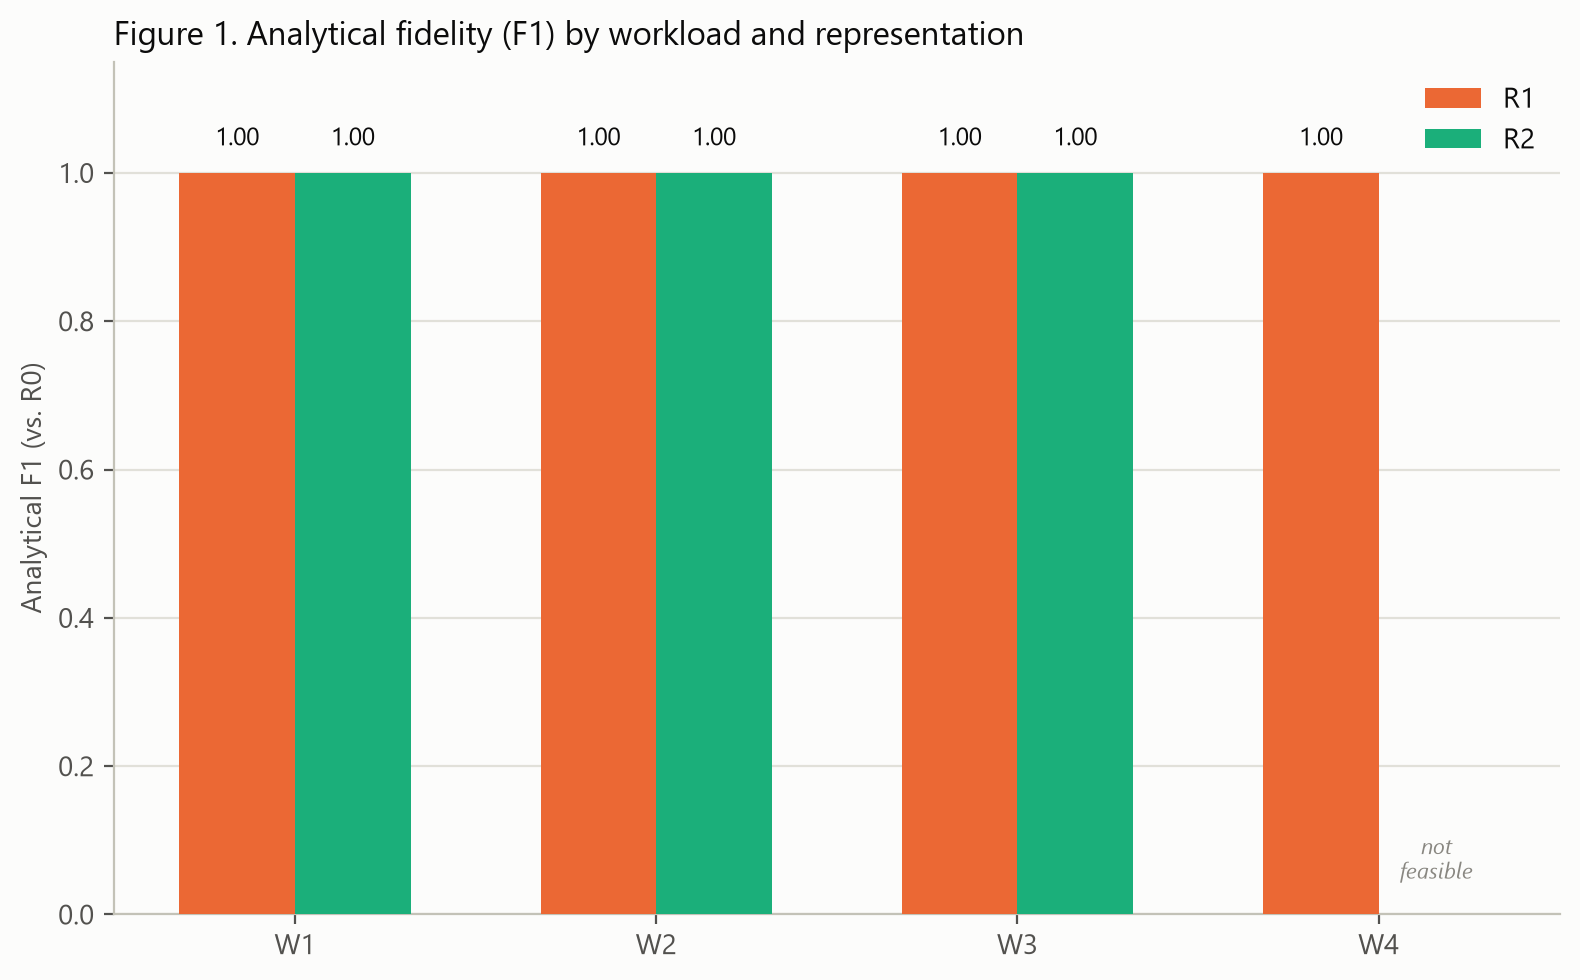

In [23]:
# Figure 1: Analytical F1 by workload and representation (feasible pairs only)
fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
bar_width = 0.32
x = np.arange(len(WORKLOADS))
f1_lookup = fidelity_df.set_index(["workload_id", "representation"])["f1"].to_dict()
feas_lookup = fidelity_df.set_index(["workload_id", "representation"])["query_feasible"].to_dict()

for offset, rep, color in [(-bar_width / 2, "R1", COLOR_R1), (bar_width / 2, "R2", COLOR_R2)]:
    heights = [f1_lookup.get((wl, rep), 0.0) if feas_lookup.get((wl, rep), False) else 0.0 for wl in WORKLOADS]
    ax.bar(x + offset, heights, width=bar_width, color=color, label=rep, zorder=3)
    for xi, wl, h in zip(x + offset, WORKLOADS, heights):
        if feas_lookup.get((wl, rep), False):
            ax.text(xi, h + 0.03, f"{h:.2f}", ha="center", va="bottom", fontsize=9, color=INK_PRIMARY)
        else:
            ax.text(xi, 0.04, "not\nfeasible", ha="center", va="bottom", fontsize=8, color=INK_MUTED, style="italic")

ax.set_ylim(0, 1.15)
ax.set_xticks(x); ax.set_xticklabels(WORKLOADS)
ax.set_ylabel("Analytical F1 (vs. R0)")
ax.set_title("Figure 1. Analytical fidelity (F1) by workload and representation", fontsize=12, color=INK_PRIMARY, loc="left")
ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig(FIG_DIR / "figure1_f1_by_workload.png", dpi=200, bbox_inches="tight")


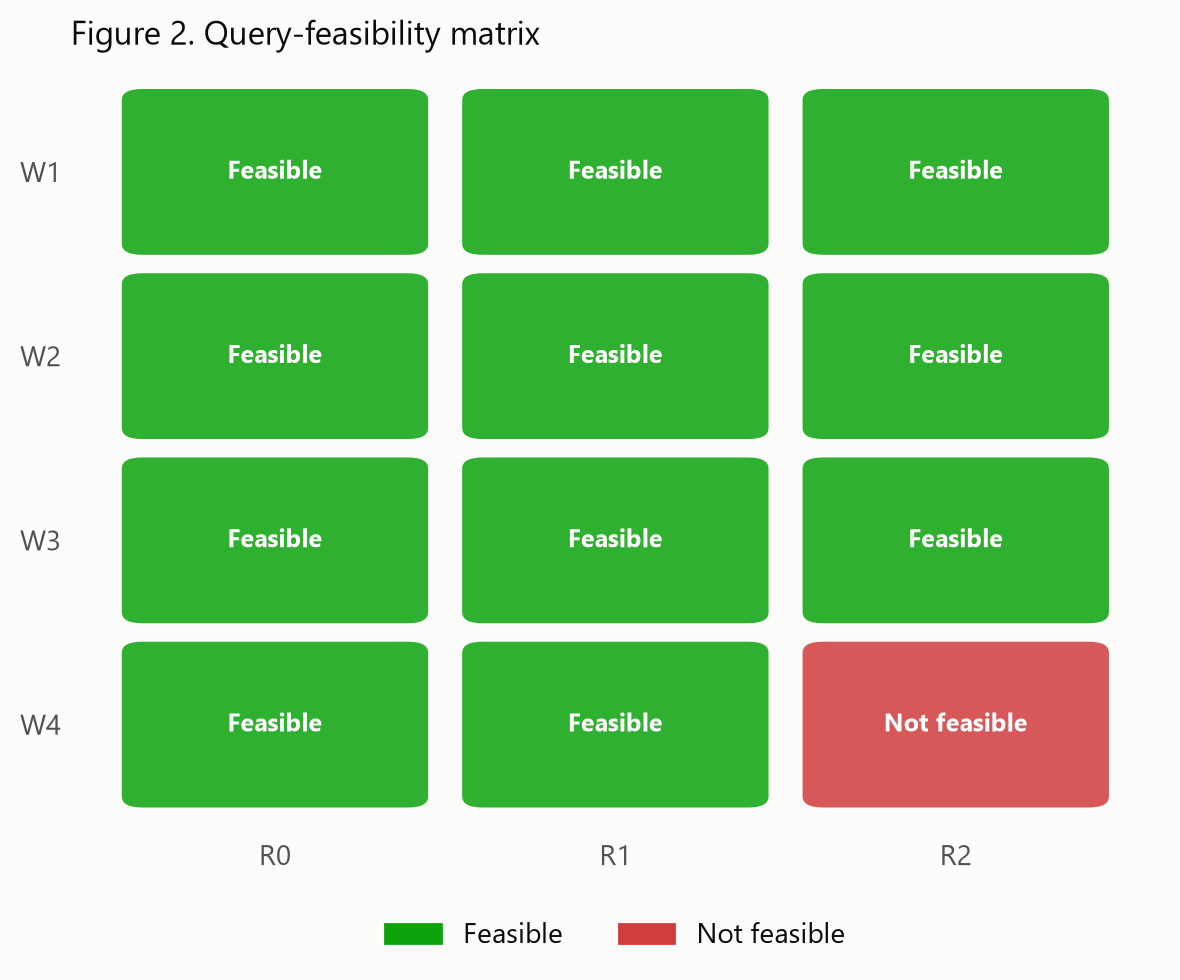

In [24]:
# Figure 2: Query-feasibility matrix
REPS = ["R0", "R1", "R2"]
status_grid = feasibility_df.pivot(index="workload_id", columns="representation", values="status").reindex(index=WORKLOADS, columns=REPS)
color_map = {"feasible": COLOR_GOOD, "not_feasible": COLOR_CRITICAL, "non_informative": INK_MUTED}

fig, ax = plt.subplots(figsize=(6, 5), dpi=200)
for i, wl in enumerate(WORKLOADS):
    for j, rep in enumerate(REPS):
        status = status_grid.loc[wl, rep]
        rect = mpatches.FancyBboxPatch((j - 0.45, len(WORKLOADS) - 1 - i - 0.45), 0.9, 0.9,
                                        boxstyle="round,pad=0,rounding_size=0.06", linewidth=0,
                                        facecolor=color_map[status], alpha=0.85, zorder=2)
        ax.add_patch(rect)
        label = {"feasible": "Feasible", "not_feasible": "Not feasible", "non_informative": "N/A"}[status]
        ax.text(j, len(WORKLOADS) - 1 - i, label, ha="center", va="center", fontsize=9, color="white", fontweight="bold", zorder=3)

ax.set_xlim(-0.6, len(REPS) - 0.4); ax.set_ylim(-0.6, len(WORKLOADS) - 0.4)
ax.set_xticks(range(len(REPS))); ax.set_xticklabels(REPS)
ax.set_yticks(range(len(WORKLOADS))); ax.set_yticklabels(list(reversed(WORKLOADS)))
ax.set_title("Figure 2. Query-feasibility matrix", fontsize=12, color=INK_PRIMARY, loc="left")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)
ax.legend(handles=[mpatches.Patch(color=COLOR_GOOD, label="Feasible"), mpatches.Patch(color=COLOR_CRITICAL, label="Not feasible")],
          frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
fig.tight_layout()
fig.savefig(FIG_DIR / "figure2_query_feasibility_matrix.png", dpi=200, bbox_inches="tight")


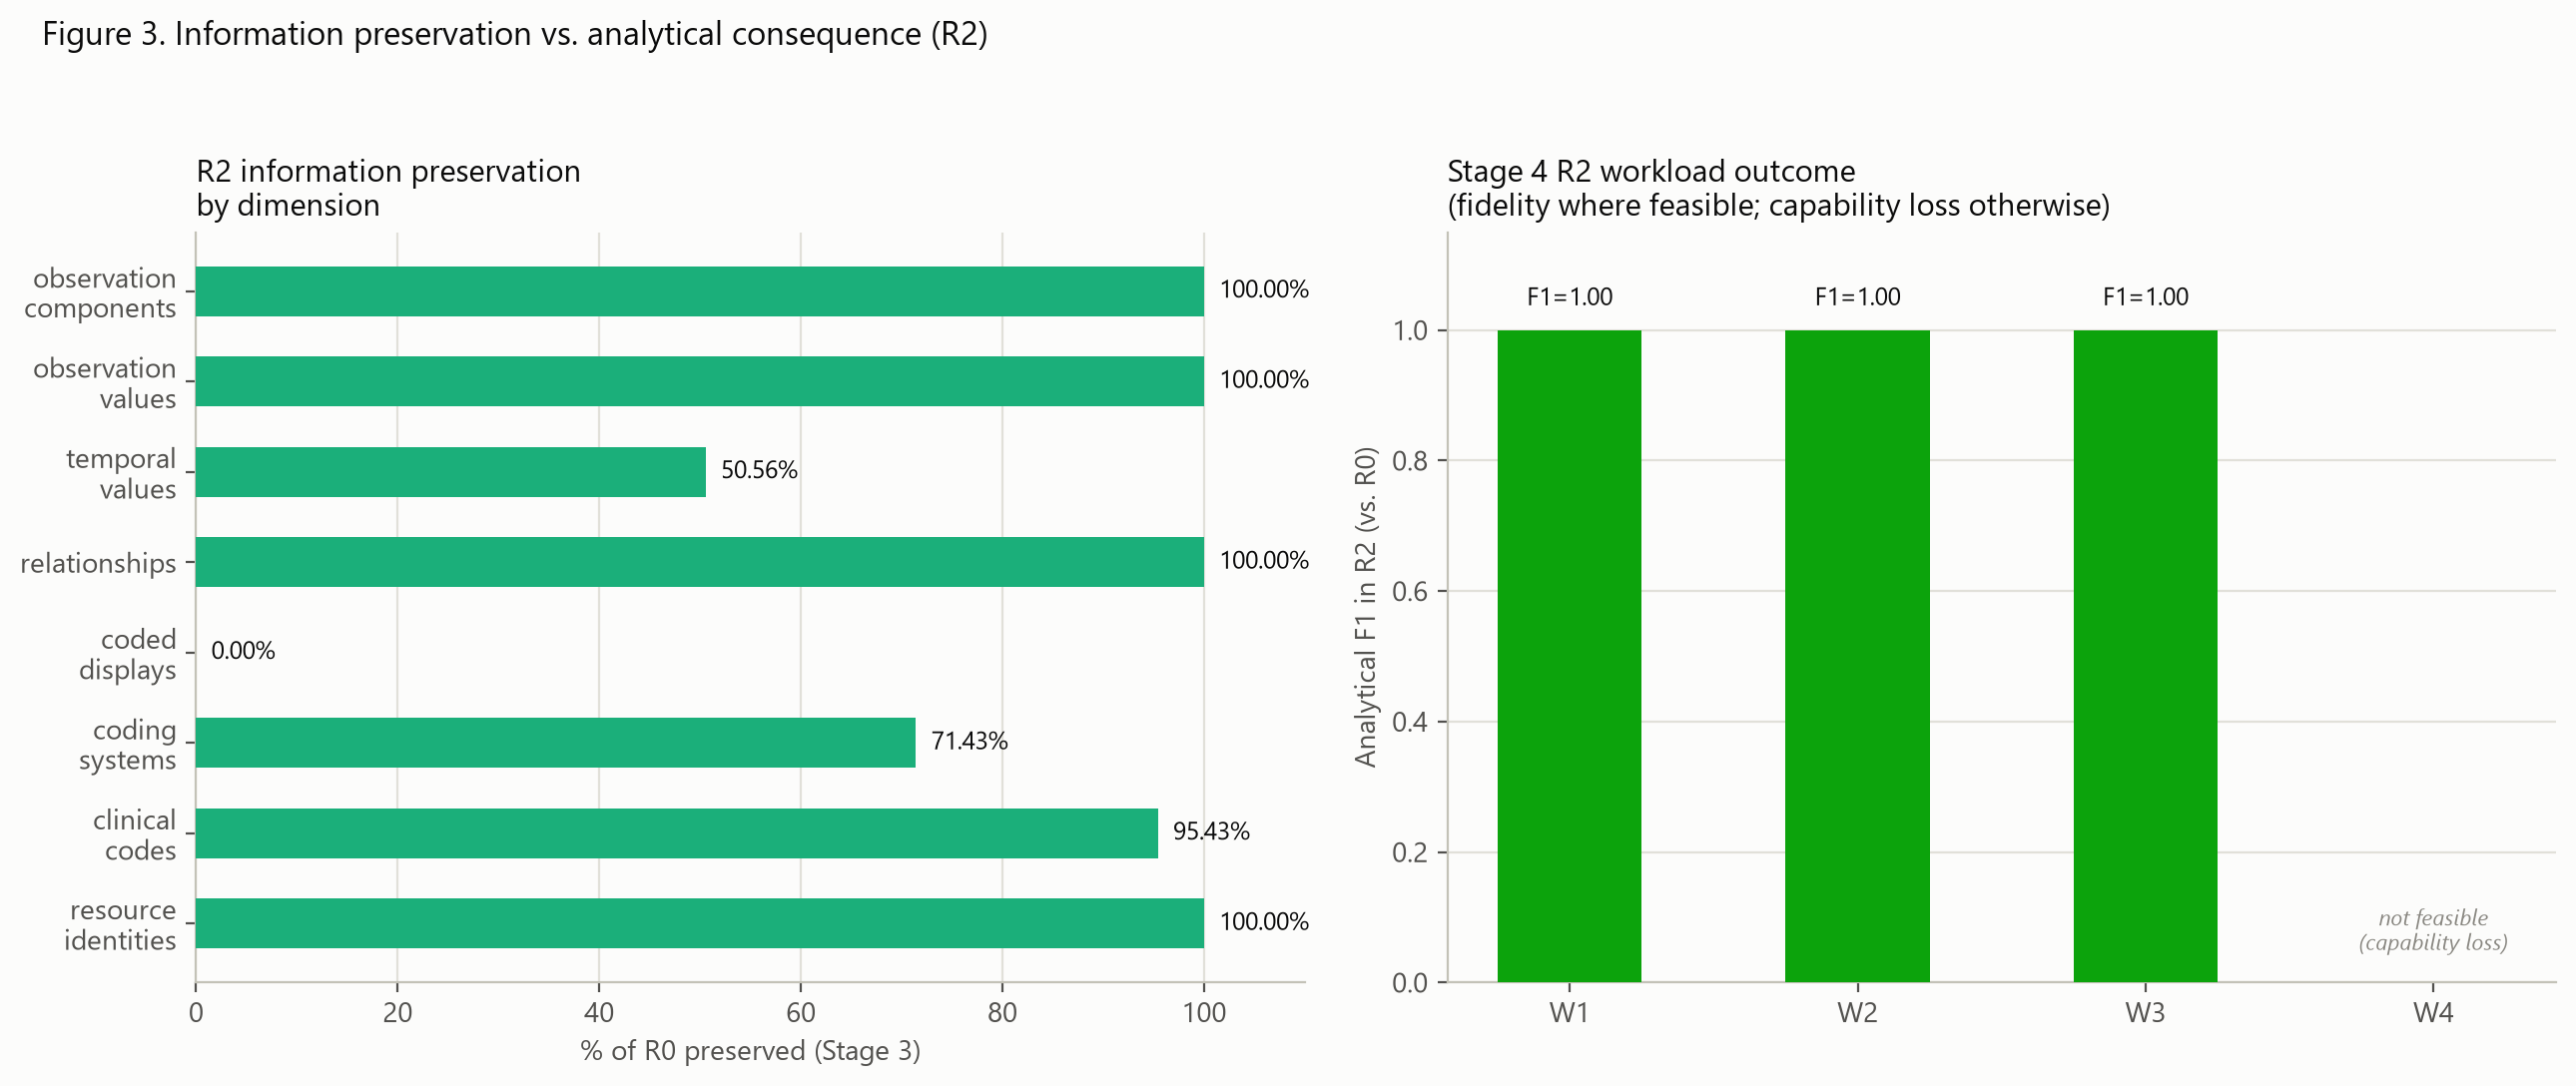

In [25]:
# Figure 3: Information preservation (Stage 3) vs analytical consequence (Stage 4), R2
preservation_r2 = {
    "resource\nidentities": pc[("resource_identities", "R2")], "clinical\ncodes": pc[("clinical_codes", "R2")],
    "coding\nsystems": pc[("coding_systems", "R2")], "coded\ndisplays": pc[("coded_displays_text", "R2")],
    "relationships": pc[("relationships", "R2")], "temporal\nvalues": pc[("temporal_values_by_semantic_type", "R2")],
    "observation\nvalues": pc[("observation_values", "R2")], "observation\ncomponents": pc[("observation_components", "R2")],
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=200)

labels1, values1 = list(preservation_r2.keys()), list(preservation_r2.values())
ax1.barh(labels1, values1, color=COLOR_R2, height=0.55, zorder=3)
for yi, v in enumerate(values1):
    ax1.text(v + 1.5, yi, f"{v:.2f}%", va="center", fontsize=9, color=INK_PRIMARY)
ax1.set_xlim(0, 110)
ax1.set_xlabel("% of R0 preserved (Stage 3)")
ax1.set_title("R2 information preservation\nby dimension", fontsize=11, color=INK_PRIMARY, loc="left")
ax1.xaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax1.set_axisbelow(True)
for s in ["top", "right"]:
    ax1.spines[s].set_visible(False)

r2_rows = fidelity_df[fidelity_df.representation == "R2"].set_index("workload_id")
values2, colors2, annotations2, feasible_flags2 = [], [], [], []
for wl in WORKLOADS:
    feasible = bool(r2_rows.loc[wl, "query_feasible"])
    feasible_flags2.append(feasible)
    if feasible:
        f1 = r2_rows.loc[wl, "f1"]
        values2.append(f1); colors2.append(COLOR_GOOD if f1 == 1.0 else COLOR_R2); annotations2.append(f"F1={f1:.2f}")
    else:
        values2.append(0.0); colors2.append(INK_MUTED); annotations2.append("not feasible\n(capability loss)")

ax2.bar(WORKLOADS, values2, color=colors2, width=0.5, zorder=3)
for xi, (a, feasible) in enumerate(zip(annotations2, feasible_flags2)):
    y = values2[xi] + 0.03 if feasible else 0.04
    ax2.text(xi, y, a, ha="center", va="bottom", fontsize=9 if feasible else 8, color=INK_PRIMARY if feasible else INK_MUTED,
              style=None if feasible else "italic")
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("Analytical F1 in R2 (vs. R0)")
ax2.set_title("Stage 4 R2 workload outcome\n(fidelity where feasible; capability loss otherwise)", fontsize=11, color=INK_PRIMARY, loc="left")
ax2.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0); ax2.set_axisbelow(True)
for s in ["top", "right"]:
    ax2.spines[s].set_visible(False)

fig.suptitle("Figure 3. Information preservation vs. analytical consequence (R2)", fontsize=12, color=INK_PRIMARY, x=0.02, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIG_DIR / "figure3_preservation_vs_consequence.png", dpi=200, bbox_inches="tight")


In [26]:
workload_definitions = {
    "W1": {"name": "Single-concept clinical cohort",
           "research_question": "Identify patients with Acute bronchitis.",
           "concept": {"system": SNOMED, "code": BRONCHITIS_CODE, "display": BRONCHITIS_DISPLAY},
           "result_set_unit": "unique Patient IDs",
           "match_rule": "coding system + code only; display text never used for matching"},
    "W2": {"name": "Cross-resource clinical cohort",
           "research_question": "Patients with Acute bronchitis who also have a MedicationRequest "
                                  "(medicationCodeableConcept) for the most frequent such medication in that cohort.",
           "result_set_unit": "unique Patient IDs", "selected_medication": selected_w2_medication},
    "W3": {"name": "Relationship-aware temporal query",
           "research_question": "Patients whose MedicationRequest.reasonReference->Condition was authored "
                                  "on/after that Condition's onsetDateTime.",
           "result_set_unit": "unique Patient IDs"},
    "W4": {"name": "Secondary temporal-semantics query",
           "research_question": "Encounters whose duration exceeds 24 hours.",
           "result_set_unit": "unique Encounter IDs",
           "duration_distribution_r0": duration_summary.iloc[0].to_dict()},
}
with open(RESULTS_DIR / "workload_definitions.json", "w", encoding="utf-8") as f:
    json.dump(workload_definitions, f, indent=2, default=str)

all_feasible_and_perfect = bool((fidelity_df.loc[fidelity_df.query_feasible, "f1"] == 1.0).all())

stage4_summary = {
    "environment": {"python_version": platform.python_version(), "pandas_version": pd.__version__,
                     "random_seed": RANDOM_SEED, "run_timestamp": datetime.now().isoformat(timespec="seconds")},
    "integrity_check_passed": True,
    "query_feasibility_summary": feasibility_df.groupby("workload_id")["status"].apply(list).to_dict(),
    "n_result_set_differences": int(len(diff_df)),
    "all_feasible_workloads_reproduced_r0_exactly": all_feasible_and_perfect,
    "w4_infeasible_in_r2": not w4_r2_feasible,
    "selected_w2_medication": selected_w2_medication,
}
with open(RESULTS_DIR / "stage4_summary.json", "w", encoding="utf-8") as f:
    json.dump(stage4_summary, f, indent=2)
None


## 15. Key Experimental Findings

These findings are limited to what this experiment actually measured on this ~100-patient
dataset; they should not be read as general claims about FHIR flattening.

- **R1 reproduced R0 exactly for every workload it was feasible for** (`W1`-`W4`): F1 = 1.0,
  zero false positives and zero false negatives in all four cases.
- **R2 reproduced R0 exactly for every workload it was feasible for** (`W1`, `W2`, `W3`): F1 =
  1.0, zero result-set differences. R2 was **not feasible** for `W4`.
- **Three of four workloads remained feasible in R2 after aggressive flattening** - the
  single-concept cohort (`W1`), the cross-resource join (`W2`), and the relationship-aware
  temporal query (`W3`). Only `W4` (encounter duration) was lost.
- **Temporal-information reduction did not affect the temporal workloads equally.** Stage 3
  measured 50.56% retention of temporal-value occurrences in R2 overall, but only `W4` was
  affected: `W3` depends solely on the *primary* timestamp each resource retains
  (`onsetDateTime`, `authoredOn`) and remained fully valid, while `W4` depends specifically on
  the *secondary* endpoint (`period.end`) that R2's one-timestamp-per-resource rule discards.
- **One workload became impossible because a required semantic distinction was removed**:
  `W4` needs two independent temporal endpoints to compute a duration, and R2 keeps only one.
  This was recorded as a capability limitation (`query_feasible = False`), not as an incorrect
  result.
- **The effect of transformation is workload-dependent, not representation-wide.** The same
  representation (R2) was perfectly faithful for three workloads and infeasible for a fourth;
  which outcome occurred was determined entirely by whether that specific workload's
  information dependency happened to survive the transformation, not by any global property of
  R2 as "more" or "less" preserving.
